In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Tuple

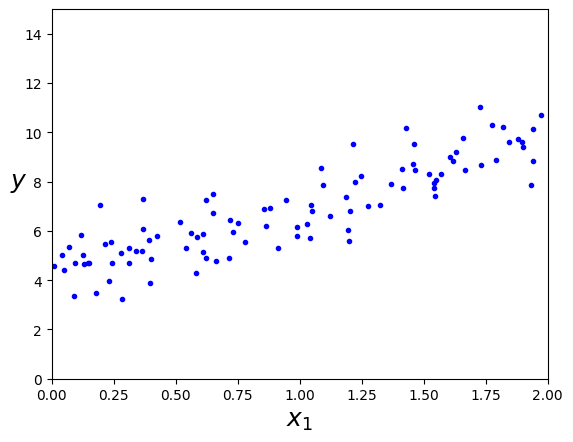

In [42]:
np.random.seed(42)
#gen some random X Y data
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

#plot the data
plt.plot(X, y, "b.")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([0, 2, 0, 15])
plt.show()


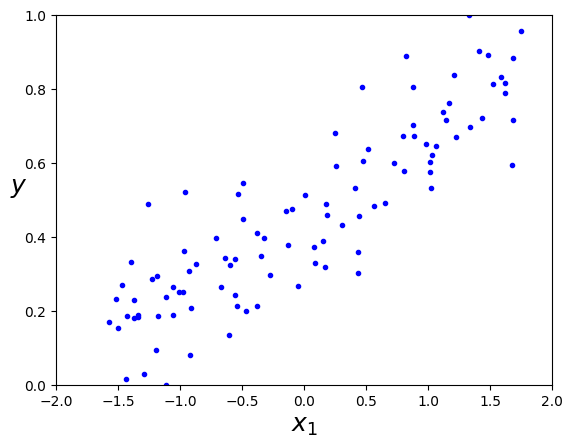

In [43]:
x = (X-np.mean(X)) / np.std(X)
x = x.reshape(-1, 1)

a, b = 0, 1

y = ((y - np.min(y)) / (np.max(y) - np.min(y))) * (b - a) + a

#plot the data
plt.plot(x, y, "b.")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([-2, 2, 0, 1])
plt.show()

In [44]:
class BayesianLinearRegression:
    def __init__(self, kernel_params, sigma2, alpha2):
        self.kernel_params = kernel_params
        self.sigma2 = sigma2
        self.alpha2 = alpha2

    def random_bases(self, x:np.ndarray) -> np.ndarray:
        indecies = np.arange(0,np.shape(x)[0])
        idx_bases = np.random.choice(indecies, self.kernel_params['num_bases'], replace=False)
        return x[idx_bases, :]
    
    def create_design_matrix(self, x:np.ndarray) -> np.ndarray:
        num_datapoints, num_bases = np.shape(x)[0], np.shape(self.bases)[0]
        Phi = np.asmatrix(np.zeros((num_datapoints, num_bases)))
        for i in range(0, num_bases):
            norm_diff = np.linalg.norm(x-np.tile(self.bases[i, :], (num_datapoints, 1)), axis=1)
            exp_kernel = np.exp(-norm_diff**2 / (2*self.kernel_params['length_scale']**2))
            Phi[:, i] = np.asmatrix(exp_kernel).T
        return np.hstack((np.ones((num_datapoints, 1)), Phi))
    
    def fit(self, x:np.ndarray, y:np.ndarray) -> None:
        self.bases = self.random_bases(x)
        self.Phi = self.create_design_matrix(x)
        num_bases = np.shape(self.bases)[0]
        N = np.shape(x)[0]
        self.V_n = ((self.alpha2**-1)*np.eye(num_bases+1) + (self.sigma2**-1)*(self.Phi.T @ self.Phi))**-1
        self.m = self.sigma2**-1 * self.V_n @ self.Phi.T @ y

    def predict(self, x_star:np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        input_size = np.shape(x_star)[0]
        Phi_star = self.create_design_matrix(x_star)
        sigma = self.sigma2*np.eye(input_size) + Phi_star @ self.V_n @ Phi_star.T
        standard_devs = np.sqrt(np.diag(sigma))
        y_star = np.asarray(Phi_star @ self.m).flatten()
        return y_star, standard_devs

In [45]:
model = BayesianLinearRegression(
    kernel_params={
        'length_scale': 0.2,
        'num_bases': 10
    },
    sigma2=0.01,
    alpha2=2
)

In [46]:
model.fit(x, y)

In [47]:
input_size = 500
x_star = np.asmatrix(np.linspace(np.min(x[:, 0]), np.max(x[:, 0]), input_size)).T

In [48]:
y_star, sigma = model.predict(x_star)

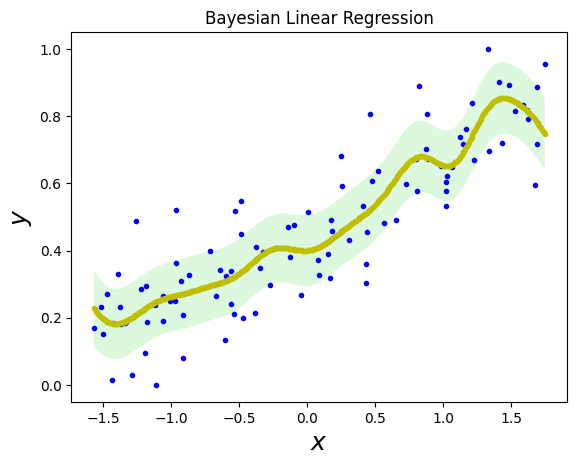

In [49]:
f = plt.figure()
plt.plot(x, y, 'b.')
_color = 'lightgreen'

plt.plot(x_star, y_star, 'y.')
plt.fill(np.concatenate([x_star, x_star[::-1]]),
            np.concatenate([y_star -sigma,
                            (y_star + sigma)[::-1]]),
            alpha=0.3, fc=_color, ec='None')
plt.xlabel('$x$', fontsize=18)
plt.ylabel('$y$', fontsize=18)
plt.title('Bayesian Linear Regression')
plt.show()